**E-Commerce Sales Analysis** <br>

## Project Overview
This project analyzes an e-commerce sales dataset to understand sales trends,
product performance, and regional revenue patterns.

The goal is to extract meaningful insights that could help businesses make
data-driven decisions.



In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## Load Dataset
The dataset contains sales transactions including product information,
customer segments, and revenue details.

In [20]:
df=pd.read_csv("/content/Sample - Superstore.csv", encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Dataset Overview
Understanding the structure of the dataset including columns,
data types, and summary statistics.

In [21]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


## Data Cleaning
In this step we clean the dataset by:
- Removing duplicates
- Handling missing values
- Converting date columns

In [22]:
df.drop_duplicates(inplace=True)

df["Order Date"] = pd.to_datetime(df["Order Date"])

df["Month"] = df["Order Date"].dt.month

## Exploratory Data Analysis
We analyze the dataset to identify patterns in sales,
regions, categories, and product performance.

### Sales by Region
This analysis shows which region contributes the most revenue.

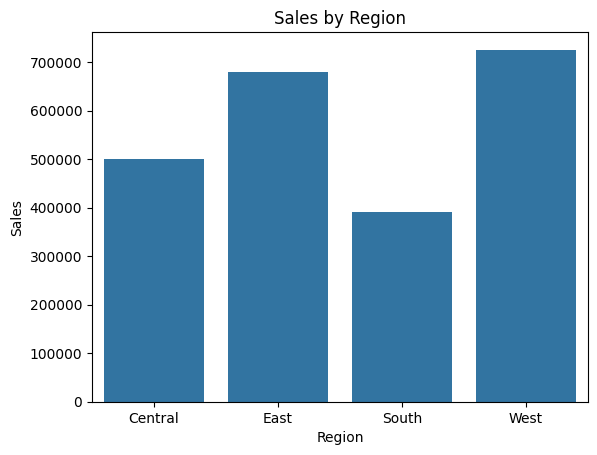

<Figure size 640x480 with 0 Axes>

In [13]:
# Sales by region

import seaborn as sns
import matplotlib.pyplot as plt

region_sales=df.groupby('Region')['Sales'].sum().reset_index()

sns.barplot(x='Region',y='Sales',data=region_sales)

plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.show()
plt.savefig('sales_by_region.png')

### Monthly Sales Trend
This visualization helps identify seasonal sales patterns.

In [14]:
#Monthly sales trend

df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Month"] = df["Order Date"].dt.month

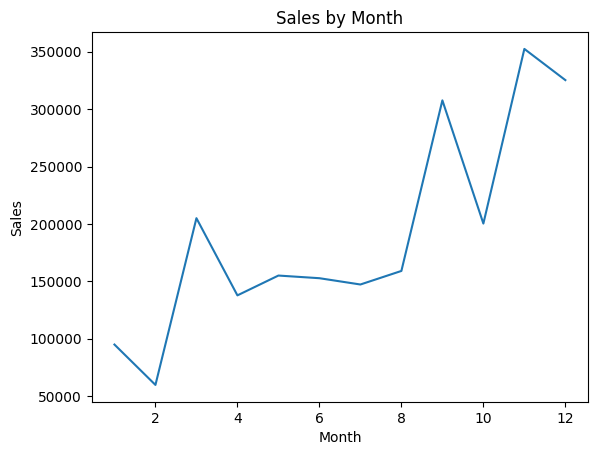

<Figure size 640x480 with 0 Axes>

In [15]:
monthly_sales=df.groupby('Month')['Sales'].sum().reset_index()

sns.lineplot(x='Month',y='Sales',data=monthly_sales)

plt.title("Sales by Month")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()
plt.savefig('sales_by_month.png')

### Top 10 Products by Sales
Identifying products generating the highest revenue.

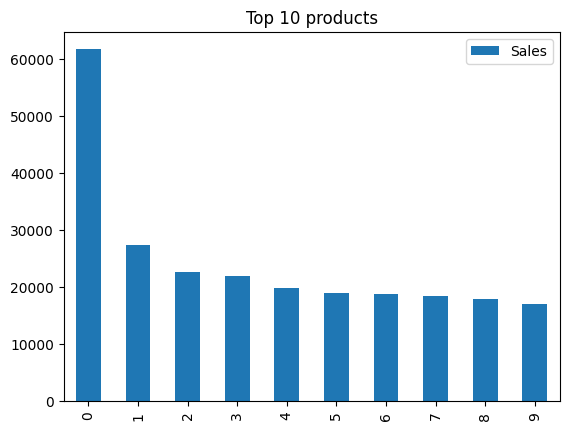

<Figure size 640x480 with 0 Axes>

In [16]:
#Top 10 Products
products=df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10).reset_index()

products.plot(kind='bar')

plt.title("Top 10 products")
plt.show()
plt.savefig('top_10_products.png')

### Sales by Category
Comparing performance across product categories.

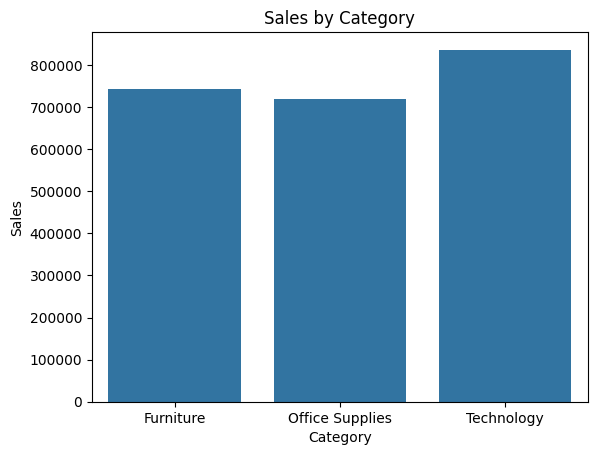

<Figure size 640x480 with 0 Axes>

In [17]:
#category performance
category_sales = df.groupby("Category")["Sales"].sum().reset_index()

sns.barplot(x="Category", y="Sales", data=category_sales)

plt.title("Sales by Category")
plt.show()
plt.savefig('sales_by_category.png')

##Sales vs Profit
Compare the relation between sales and profit

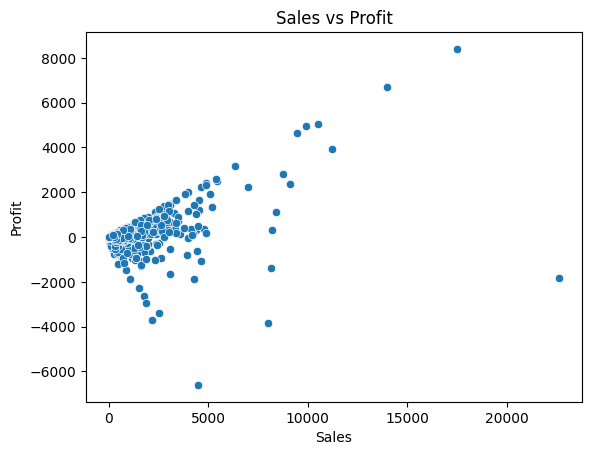

<Figure size 640x480 with 0 Axes>

In [18]:
#profit vs sales relationship
sns.scatterplot(x="Sales", y="Profit", data=df)

plt.title("Sales vs Profit")
plt.show()
plt.savefig('sales_vs_profit.png')

## Key Business Insights

1. The West region generates the highest revenue.
2. Technology category contributes the most sales.
3. Sales peak during holiday months.
4. A small number of products contribute significantly to revenue.

These insights could help businesses optimize inventory,
marketing campaigns, and regional strategies.